# Madrid Rental Market — Exploratory Data Analysis
### Inside Airbnb Dataset

**Author:** Alejandro Abadal  
**Dataset:** [Inside Airbnb — Madrid](http://insideairbnb.com/get-the-data/)  
**Last updated:** 2026

---

## Goal

Explore Madrid's short-term rental market using real Airbnb data to answer questions such as:

- What is the average nightly price in Madrid by neighbourhood?
- Which type of accommodation dominates the market?
- Is there a correlation between price and number of reviews?
- Which are the most expensive and most affordable neighbourhoods?
- How are prices distributed geographically?

## Notebook structure

1. Data loading & first look  
2. Data cleaning  
3. Univariate analysis  
4. Analysis by accommodation type  
5. Geographic analysis by neighbourhood  
6. Correlations  
7. Interactive map  
8. Conclusions  

---
## 0. Setup

In [2]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import folium
from folium.plugins import HeatMap
import warnings

from utils import set_style, basic_cleaning, save_fig, fmt_euro, top_neighbourhoods, PALETTE, PRIMARY, ACCENT

warnings.filterwarnings('ignore')
set_style()

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 1. Data loading

> **How to get the data:**  
> 1. Go to http://insideairbnb.com/get-the-data/  
> 2. Search for **Madrid, Spain**  
> 3. Download `listings.csv.gz` (the detailed file)  
> 4. Place it in `data/raw/listings.csv.gz`

In [3]:
DATA_PATH = '../data/raw/listings.csv.gz'

df_raw = pd.read_csv(DATA_PATH, low_memory=False)

print(f'Raw shape: {df_raw.shape}')
print(f'Columns: {df_raw.shape[1]}')
df_raw.head(3)

Raw shape: (25000, 79)
Columns: 79


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,21853,https://www.airbnb.com/rooms/21853,20250914152907,2025-09-15,previous scrape,Bright and airy room,We have a quiet and sunny room with a good vie...,We live in a leafy neighbourhood with plenty o...,https://a0.muscache.com/pictures/68483181/87bc...,83531,...,4.82,4.21,4.67,NaN,f,2,0,2,0,0.25
1,30320,https://www.airbnb.com/rooms/30320,20250914152907,2025-09-15,city scrape,Apartamentos Dana Sol,NaN,NaN,https://a0.muscache.com/pictures/336868/f67409...,130907,...,4.78,4.90,4.69,NaN,t,17,17,0,0,0.93
2,30959,https://www.airbnb.com/rooms/30959,20250914152907,2025-09-15,previous scrape,Beautiful loft in Madrid Center,Beautiful Loft 60m2 size just in the historica...,NaN,https://a0.muscache.com/pictures/78173471/835e...,132883,...,4.63,4.88,4.25,NaN,f,1,1,0,0,0.06


In [4]:
# Select relevant columns for the analysis
COLS = [
    'id', 'name', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed',
    'latitude', 'longitude', 'room_type', 'accommodates', 'bathrooms_text',
    'bedrooms', 'beds', 'price', 'minimum_nights', 'maximum_nights',
    'number_of_reviews', 'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'reviews_per_month', 'host_is_superhost',
    'host_listings_count', 'instant_bookable', 'availability_365'
]

cols_available = [c for c in COLS if c in df_raw.columns]
df = df_raw[cols_available].copy()

print(f'Selected columns: {len(cols_available)}')
df.dtypes

Selected columns: 23


id                                int64
name                                str
neighbourhood_cleansed              str
neighbourhood_group_cleansed        str
latitude                        float64
longitude                       float64
room_type                           str
accommodates                      int64
bathrooms_text                      str
bedrooms                        float64
beds                            float64
price                               str
minimum_nights                    int64
maximum_nights                    int64
number_of_reviews                 int64
review_scores_rating            float64
review_scores_cleanliness       float64
review_scores_location          float64
reviews_per_month               float64
host_is_superhost                   str
host_listings_count             float64
instant_bookable                    str
availability_365                  int64
dtype: object

---
## 2. Data Cleaning

In [5]:
# Overview of missing values
nulls = df.isnull().sum()
nulls_pct = (nulls / len(df) * 100).round(1)
null_df = pd.DataFrame({'missing': nulls, '%': nulls_pct})
null_df[null_df['missing'] > 0].sort_values('%', ascending=False)

,missing,%
price,6047,24.2
beds,6035,24.1
review_scores_location,5150,20.6
reviews_per_month,5147,20.6
review_scores_rating,5147,20.6
review_scores_cleanliness,5148,20.6
bedrooms,2512,10.0
host_is_superhost,668,2.7
host_listings_count,97,0.4
bathrooms_text,28,0.1


  Figure saved -> ../outputs/figures/00_missing_values.png


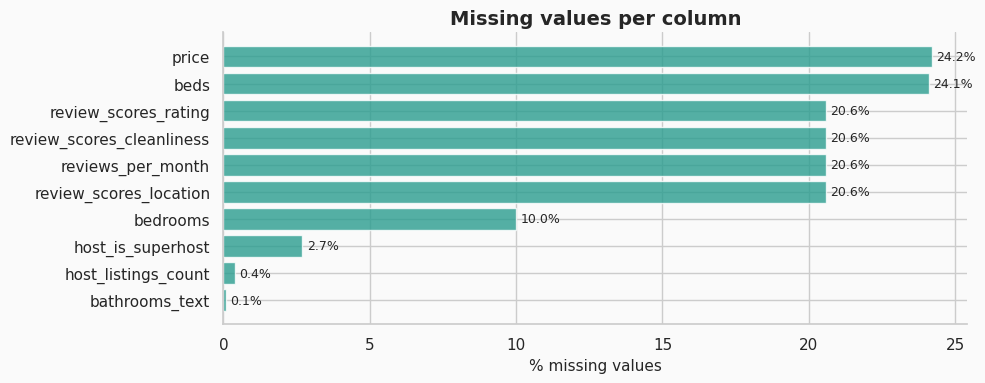

In [6]:
# Missing values chart
fig, ax = plt.subplots(figsize=(10, 4))
null_pcts = null_df[null_df['missing'] > 0]['%'].sort_values()
bars = ax.barh(null_pcts.index, null_pcts.values, color=PRIMARY, alpha=0.8)
ax.bar_label(bars, labels=[f'{v:.1f}%' for v in null_pcts.values], padding=3, fontsize=9)
ax.set_xlabel('% missing values')
ax.set_title('Missing values per column')
plt.tight_layout()
save_fig(fig, '00_missing_values')
plt.show()

In [7]:
# Apply cleaning pipeline
df = basic_cleaning(df)

# Convert superhost to boolean
if 'host_is_superhost' in df.columns:
    df['host_is_superhost'] = df['host_is_superhost'].map({'t': True, 'f': False})

# Convert instant_bookable to boolean
if 'instant_bookable' in df.columns:
    df['instant_bookable'] = df['instant_bookable'].map({'t': True, 'f': False})

print(f'Clean dataset shape: {df.shape}')
df.describe()

── Data cleaning ──────────────────────────────
  Initial rows: 25,000
  Rows dropped (no price/coords): 6047
  Outliers removed: 350 (1.8%)
  Final rows: 18,601
───────────────────────────────────────────────

Clean dataset shape: (18601, 23)


,id,latitude,longitude,accommodates,bedrooms,beds,price,minimum_nights,maximum_nights,number_of_reviews,review_scores_rating,review_scores_cleanliness,review_scores_location,reviews_per_month,host_listings_count,availability_365
count,1.860100e+04,18601.000000,18601.000000,18601.000000,18574.000000,18588.000000,18601.000000,18601.000000,18601.000000,18601.000000,15635.000000,15634.000000,15635.000000,15635.000000,18508.000000,18601.000000
mean,8.260865e+17,40.422631,-3.694063,3.298694,1.372725,1.970949,132.404172,8.190904,498.596097,60.443041,4.630943,4.679117,4.734755,2.051277,70.861033,213.122950
std,5.460917e+17,0.023374,0.027208,1.897770,0.909299,1.443961,96.639124,18.821032,381.363421,104.134226,0.482053,0.440592,0.380666,2.074112,161.333359,115.720785
min,3.032000e+04,40.331400,-3.832060,1.000000,0.000000,0.000000,21.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.010000,1.000000,0.000000
25%,5.291679e+07,40.410202,-3.707305,2.000000,1.000000,1.000000,71.000000,1.000000,364.000000,2.000000,4.540000,4.600000,4.650000,0.540000,2.000000,98.000000
50%,9.990393e+17,40.420740,-3.700938,3.000000,1.000000,2.000000,110.000000,2.000000,365.000000,18.000000,4.750000,4.790000,4.850000,1.420000,7.000000,246.000000
75%,1.292733e+18,40.432411,-3.685110,4.000000,2.000000,2.000000,161.000000,4.000000,730.000000,70.000000,4.900000,4.930000,4.960000,2.970000,44.000000,318.000000
max,1.508659e+18,40.535530,-3.545904,16.000000,25.000000,40.000000,790.000000,365.000000,1125.000000,1184.000000,5.000000,5.000000,5.000000,51.260000,1192.000000,365.000000


---
## 3. Univariate Analysis

### 3.1 Price distribution

  Figure saved -> ../outputs/figures/01_price_distribution.png


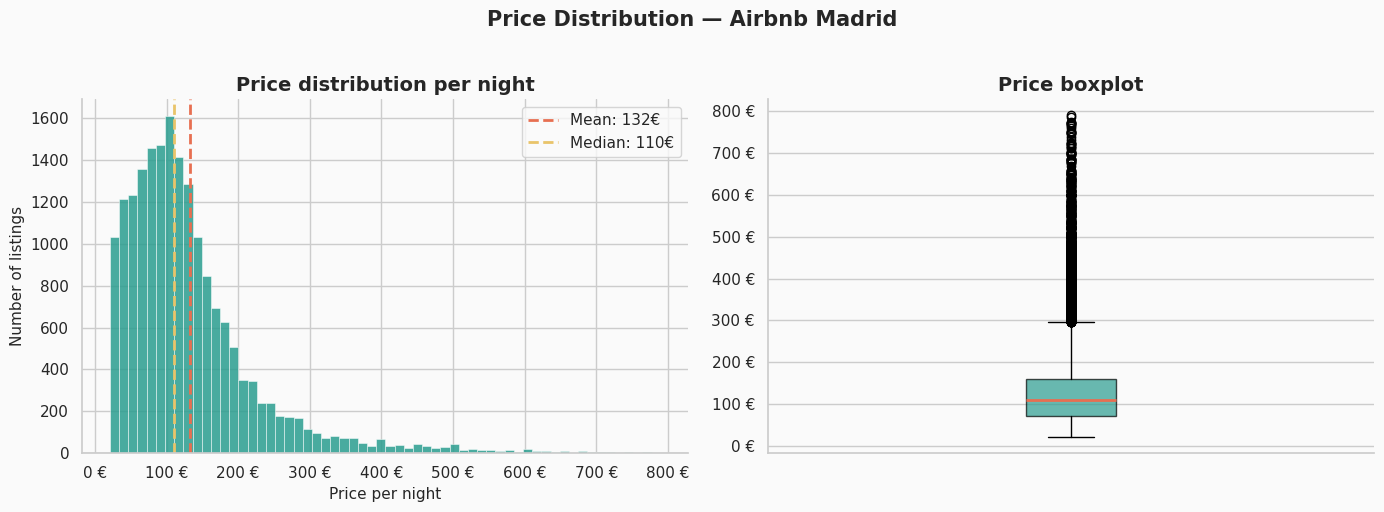


Price statistics:
count    18601.00 €
mean       132.40 €
std         96.64 €
min         21.00 €
25%         71.00 €
50%        110.00 €
75%        161.00 €
max        790.00 €
Name: price, dtype: str


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['price'], bins=60, color=PRIMARY, alpha=0.85, edgecolor='white', linewidth=0.4)
axes[0].axvline(df['price'].mean(),   color=ACCENT, lw=2, ls='--', label=f"Mean: {df['price'].mean():.0f}€")
axes[0].axvline(df['price'].median(), color='#e9c46a', lw=2, ls='--', label=f"Median: {df['price'].median():.0f}€")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_euro))
axes[0].set_xlabel('Price per night')
axes[0].set_ylabel('Number of listings')
axes[0].set_title('Price distribution per night')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor=PRIMARY, alpha=0.7),
                medianprops=dict(color=ACCENT, linewidth=2))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_euro))
axes[1].set_title('Price boxplot')
axes[1].set_xticks([])

plt.suptitle('Price Distribution — Airbnb Madrid', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, '01_price_distribution')
plt.show()

print('\nPrice statistics:')
print(df['price'].describe().apply(lambda x: f'{x:.2f} €'))

---
## 4. Analysis by Accommodation Type

  Figure saved -> ../outputs/figures/02_accommodation_type.png


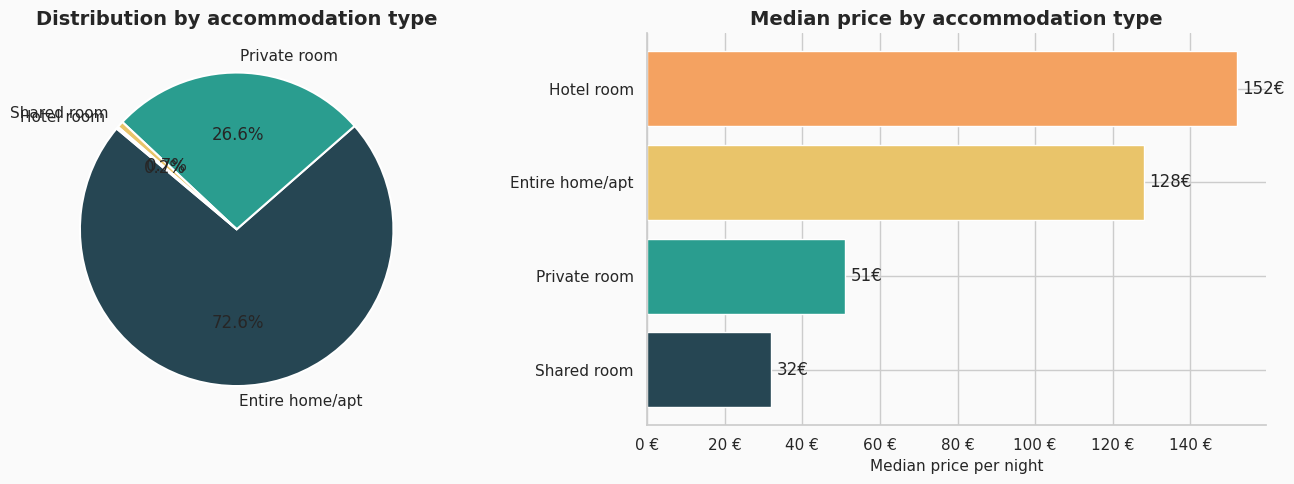

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution by type
room_counts = df['room_type'].value_counts()
axes[0].pie(
    room_counts.values,
    labels=room_counts.index,
    autopct='%1.1f%%',
    colors=PALETTE,
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
axes[0].set_title('Distribution by accommodation type')

# Median price by type
price_by_room = df.groupby('room_type')['price'].median().sort_values(ascending=True)
bars = axes[1].barh(price_by_room.index, price_by_room.values, color=PALETTE[:len(price_by_room)])
axes[1].bar_label(bars, labels=[f'{v:.0f}€' for v in price_by_room.values], padding=4)
axes[1].set_xlabel('Median price per night')
axes[1].set_title('Median price by accommodation type')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_euro))

plt.tight_layout()
save_fig(fig, '02_accommodation_type')
plt.show()

  Figure saved -> ../outputs/figures/03_violin_type.png


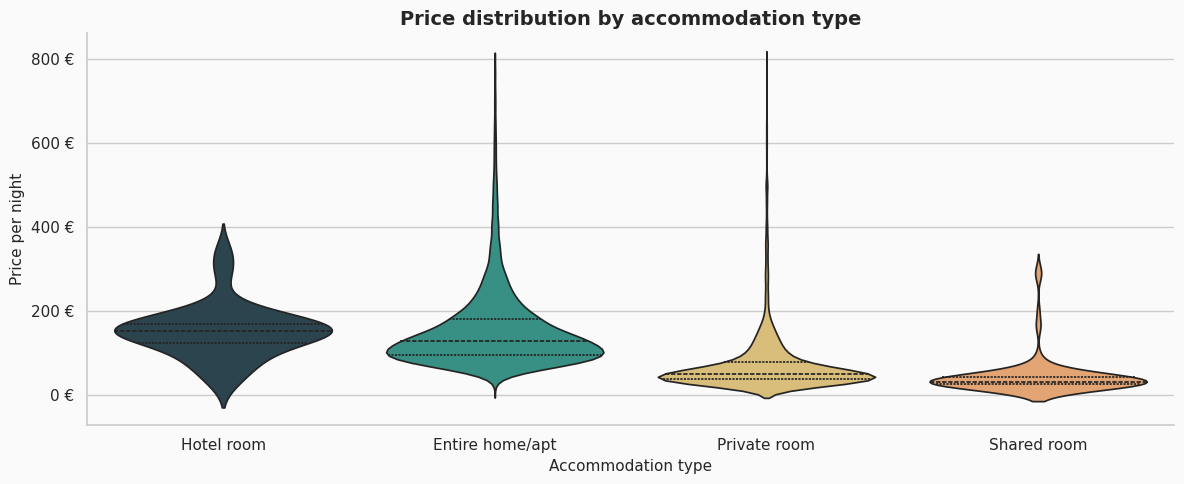

In [10]:
# Violin plot — price distribution by type
fig, ax = plt.subplots(figsize=(12, 5))

order = df.groupby('room_type')['price'].median().sort_values(ascending=False).index
sns.violinplot(
    data=df, x='room_type', y='price',
    order=order, palette=PALETTE,
    inner='quartile', ax=ax
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_euro))
ax.set_xlabel('Accommodation type')
ax.set_ylabel('Price per night')
ax.set_title('Price distribution by accommodation type')
plt.tight_layout()
save_fig(fig, '03_violin_type')
plt.show()

---
## 5. Geographic Analysis by Neighbourhood

  Figure saved -> ../outputs/figures/04_top_neighbourhoods_listings.png


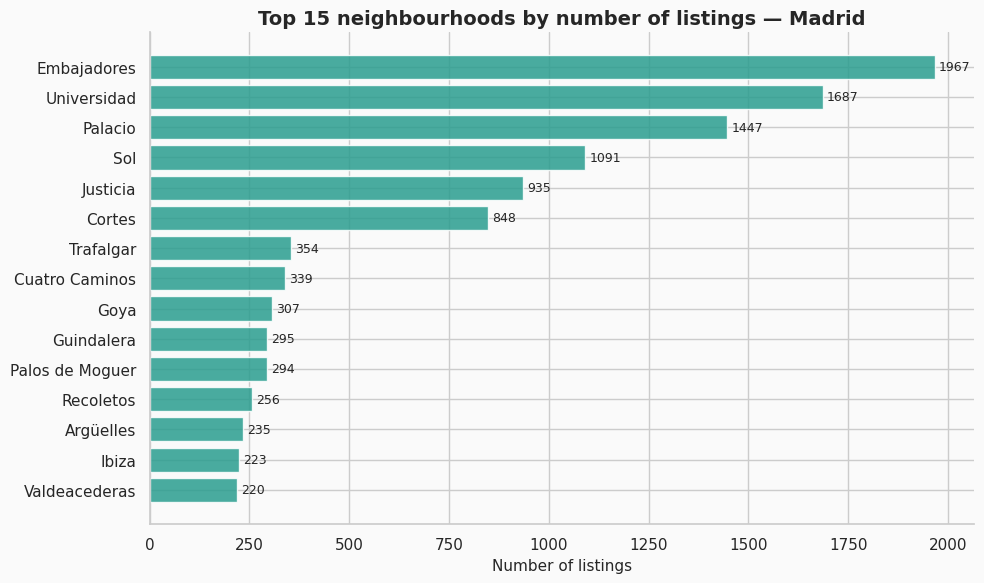

In [11]:
# Top 15 neighbourhoods by number of listings
top_barrios = top_neighbourhoods(df, n=15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_barrios.index[::-1], top_barrios.values[::-1], color=PRIMARY, alpha=0.85)
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel('Number of listings')
ax.set_title('Top 15 neighbourhoods by number of listings — Madrid')
plt.tight_layout()
save_fig(fig, '04_top_neighbourhoods_listings')
plt.show()

  Figure saved -> ../outputs/figures/05_price_by_neighbourhood.png


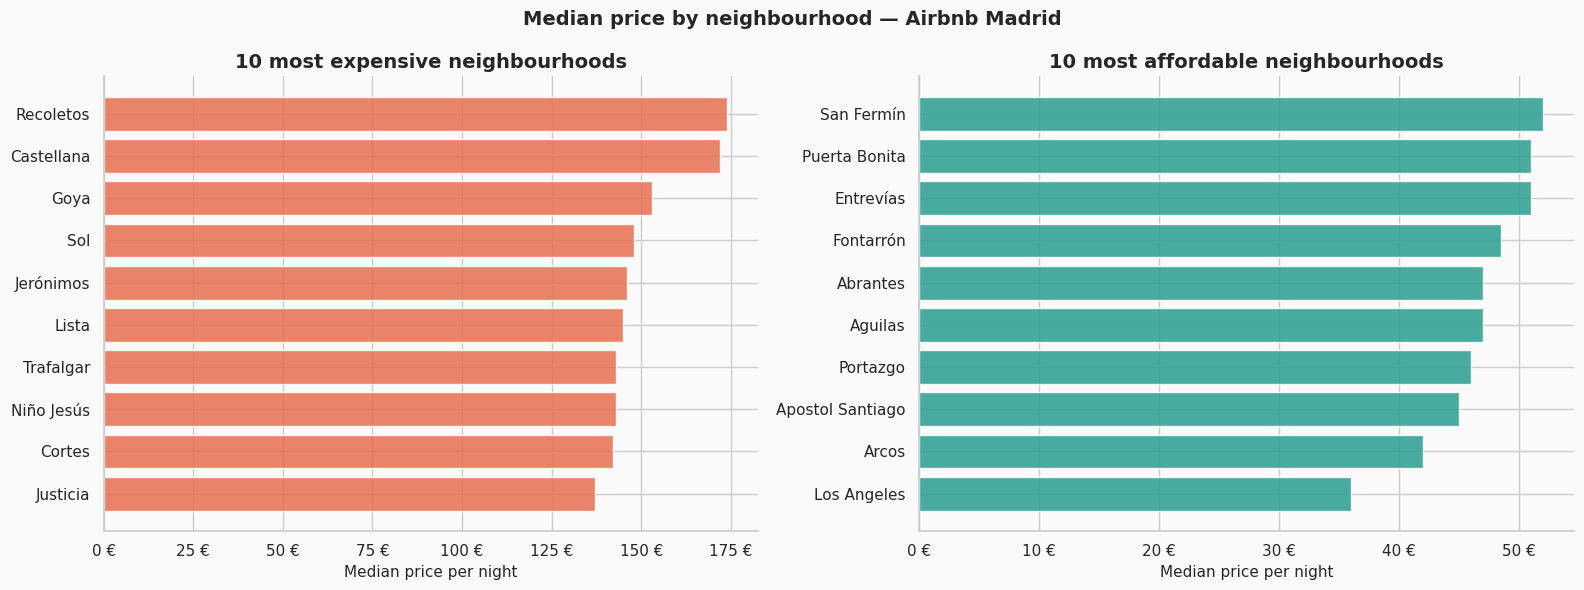

In [12]:
# Median price by neighbourhood — top and bottom 10
price_by_barrio = (
    df.groupby('neighbourhood_cleansed')['price']
    .agg(['median', 'count'])
    .rename(columns={'median': 'median_price', 'count': 'n_listings'})
    .query('n_listings >= 30')
    .sort_values('median_price', ascending=False)
)

top10    = price_by_barrio.head(10)
bottom10 = price_by_barrio.tail(10).sort_values('median_price')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Most expensive
axes[0].barh(top10.index[::-1], top10['median_price'][::-1], color=ACCENT, alpha=0.85)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_euro))
axes[0].set_title('10 most expensive neighbourhoods')
axes[0].set_xlabel('Median price per night')

# Most affordable
axes[1].barh(bottom10.index, bottom10['median_price'], color=PRIMARY, alpha=0.85)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_euro))
axes[1].set_title('10 most affordable neighbourhoods')
axes[1].set_xlabel('Median price per night')

plt.suptitle('Median price by neighbourhood — Airbnb Madrid', fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig(fig, '05_price_by_neighbourhood')
plt.show()

  Figure saved -> ../outputs/figures/06_price_by_district.png


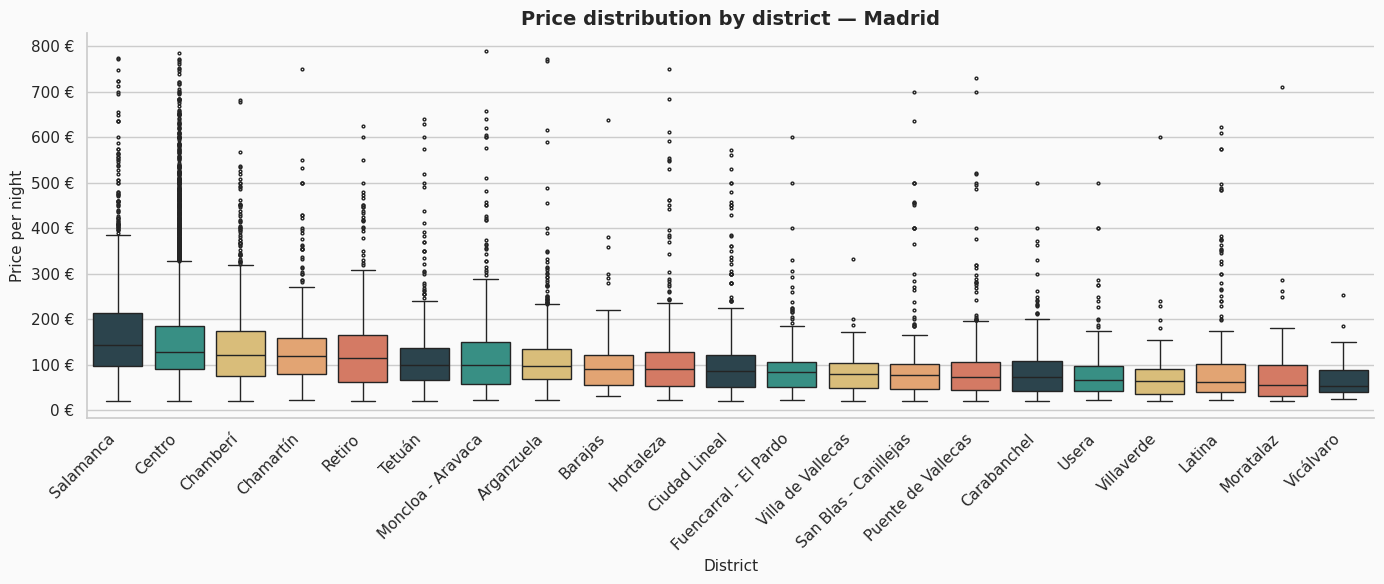

In [13]:
# Boxplot by district
if 'neighbourhood_group_cleansed' in df.columns:
    order_dist = (
        df.groupby('neighbourhood_group_cleansed')['price']
        .median().sort_values(ascending=False).index
    )
    fig, ax = plt.subplots(figsize=(14, 6))
    sns.boxplot(
        data=df, x='neighbourhood_group_cleansed', y='price',
        order=order_dist, palette=PALETTE * 4,
        fliersize=2, ax=ax
    )
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_euro))
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_xlabel('District')
    ax.set_ylabel('Price per night')
    ax.set_title('Price distribution by district — Madrid')
    plt.tight_layout()
    save_fig(fig, '06_price_by_district')
    plt.show()

---
## 6. Correlations & Multivariate Analysis

  Figure saved -> ../outputs/figures/07_correlation_matrix.png


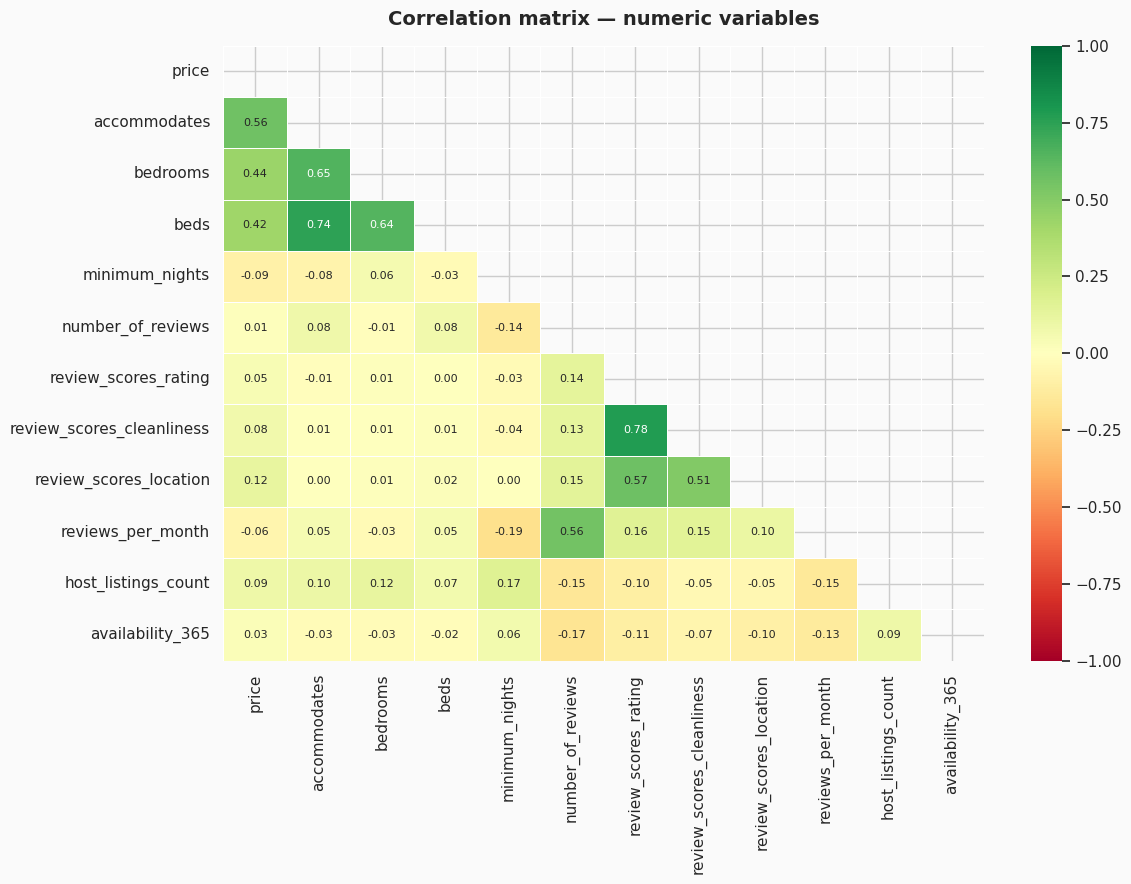

In [14]:
# Select relevant numeric variables
num_cols = [
    'price', 'accommodates', 'bedrooms', 'beds',
    'minimum_nights', 'number_of_reviews',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'reviews_per_month',
    'host_listings_count', 'availability_365'
]
num_cols = [c for c in num_cols if c in df.columns]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={'size': 8}
)
ax.set_title('Correlation matrix — numeric variables', pad=15)
plt.tight_layout()
save_fig(fig, '07_correlation_matrix')
plt.show()

  Figure saved -> ../outputs/figures/08_price_vs_capacity.png


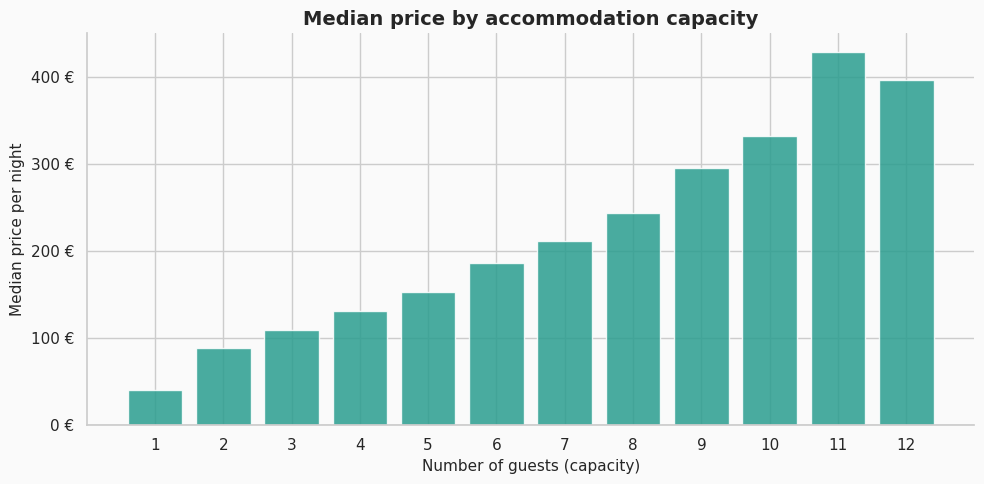

In [15]:
# Price vs capacity (accommodates)
if 'accommodates' in df.columns:
    price_by_acc = df.groupby('accommodates')['price'].median().reset_index()
    price_by_acc = price_by_acc[price_by_acc['accommodates'] <= 12]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(price_by_acc['accommodates'], price_by_acc['price'], color=PRIMARY, alpha=0.85, edgecolor='white')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_euro))
    ax.set_xlabel('Number of guests (capacity)')
    ax.set_ylabel('Median price per night')
    ax.set_title('Median price by accommodation capacity')
    ax.set_xticks(price_by_acc['accommodates'])
    plt.tight_layout()
    save_fig(fig, '08_price_vs_capacity')
    plt.show()

  Figure saved -> ../outputs/figures/09_superhost.png


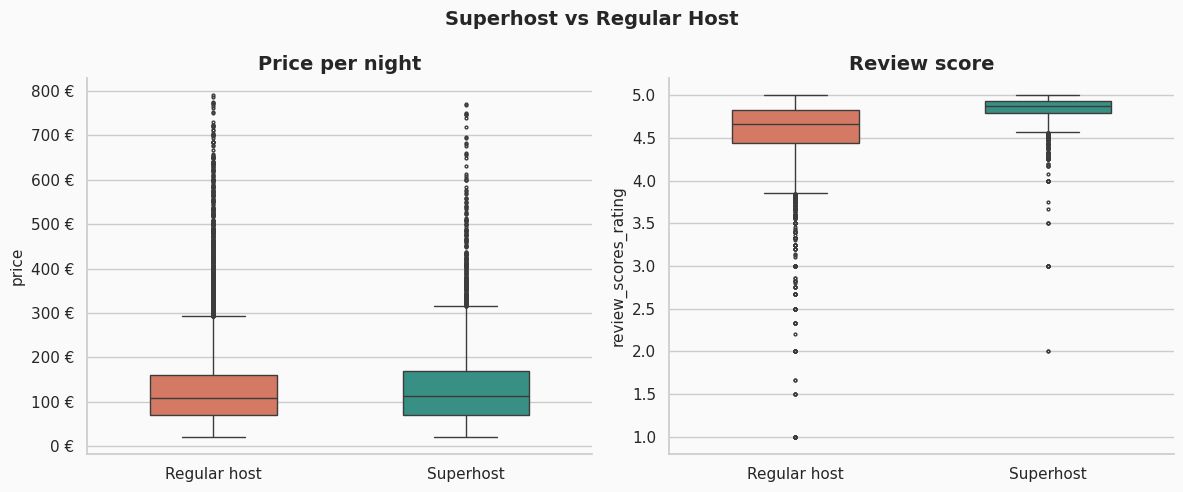

In [16]:
# Superhost vs regular host
if 'host_is_superhost' in df.columns:
    sh_df = df.dropna(subset=['host_is_superhost'])
    sh_df['superhost_label'] = sh_df['host_is_superhost'].map({True: 'Superhost', False: 'Regular host'})

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Price
    sns.boxplot(
        data=sh_df, x='superhost_label', y='price',
        palette=[ACCENT, PRIMARY], ax=axes[0], width=0.5, fliersize=2
    )
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_euro))
    axes[0].set_title('Price per night')
    axes[0].set_xlabel('')

    # Rating
    if 'review_scores_rating' in sh_df.columns:
        sns.boxplot(
            data=sh_df.dropna(subset=['review_scores_rating']),
            x='superhost_label', y='review_scores_rating',
            palette=[ACCENT, PRIMARY], ax=axes[1], width=0.5, fliersize=2
        )
        axes[1].set_title('Review score')
        axes[1].set_xlabel('')

    plt.suptitle('Superhost vs Regular Host', fontsize=14, fontweight='bold')
    plt.tight_layout()
    save_fig(fig, '09_superhost')
    plt.show()

---
## 7. Interactive Price Map

In [17]:
# Price heatmap with Folium
madrid_center = [40.4168, -3.7038]
mapa = folium.Map(location=madrid_center, zoom_start=12, tiles='CartoDB positron')

# Random sample to avoid overloading the map
sample = df.sample(min(3000, len(df)), random_state=42)

# Heatmap weighted by price
heat_data = [
    [row['latitude'], row['longitude'], row['price']]
    for _, row in sample.iterrows()
]
HeatMap(heat_data, radius=10, blur=15, min_opacity=0.3).add_to(mapa)

title_html = '''
    <div style="position: fixed; top: 10px; left: 50%; transform: translateX(-50%);
                background: white; padding: 10px 20px; border-radius: 8px;
                box-shadow: 0 2px 10px rgba(0,0,0,0.2); z-index: 1000;
                font-family: Arial; font-size: 14px; font-weight: bold;">
        Price Heatmap — Airbnb Madrid
    </div>
'''
mapa.get_root().html.add_child(folium.Element(title_html))

mapa_path = '../outputs/price_heatmap_madrid.html'
mapa.save(mapa_path)
print(f'Map saved to: {mapa_path}')
mapa

Map saved to: ../outputs/price_heatmap_madrid.html


In [18]:
# Scatter map coloured by accommodation type
fig_map = px.scatter_mapbox(
    sample,
    lat='latitude', lon='longitude',
    color='room_type',
    size='price',
    size_max=15,
    hover_data={'price': True, 'neighbourhood_cleansed': True, 'room_type': True},
    color_discrete_sequence=PALETTE,
    mapbox_style='carto-positron',
    zoom=11,
    center={'lat': 40.4168, 'lon': -3.7038},
    title='Airbnb listings in Madrid — price & type',
    height=600
)
fig_map.update_layout(margin=dict(l=0, r=0, t=40, b=0))
fig_map.show()

---
## 8. Conclusions

In [19]:
from IPython.display import display, Markdown

# ── Compute stats from the actual data ──────────────────────────────────────
median_price      = df['price'].median()
mean_price        = df['price'].mean()
total_listings    = len(df)

top_room          = df['room_type'].value_counts().idxmax()
top_room_pct      = df['room_type'].value_counts(normalize=True).max() * 100

most_expensive_nb = (
    df.groupby('neighbourhood_cleansed')['price']
    .median().idxmax()
)
most_expensive_val = df.groupby('neighbourhood_cleansed')['price'].median().max()

most_affordable_nb = (
    df.groupby('neighbourhood_cleansed')['price']
    .median().idxmin()
)
most_affordable_val = df.groupby('neighbourhood_cleansed')['price'].median().min()

# Correlation with price
num_cols_corr = ['accommodates', 'bedrooms', 'beds', 'review_scores_rating',
                 'number_of_reviews', 'availability_365']
num_cols_corr = [c for c in num_cols_corr if c in df.columns]
corr_with_price = df[num_cols_corr + ['price']].corr()['price'].drop('price')
top_corr_feat   = corr_with_price.abs().idxmax()
top_corr_val    = corr_with_price[top_corr_feat]

superhost_median = None
regular_median   = None
if 'host_is_superhost' in df.columns:
    sh = df.dropna(subset=['host_is_superhost'])
    superhost_median = sh[sh['host_is_superhost'] == True]['price'].median()
    regular_median   = sh[sh['host_is_superhost'] == False]['price'].median()

# ── Build auto summary ───────────────────────────────────────────────────────
superhost_line = (
    f"| 5 | **Superhosts** obtain slightly higher review scores; "
    f"median price Superhost={superhost_median:.0f}€ vs Regular={regular_median:.0f}€ |"
    if superhost_median else ""
)

summary = f"""
### Key findings

| # | Finding |
|---|---------|
| 1 | The median nightly price in Madrid is **{median_price:.0f} €** (mean: {mean_price:.0f} €) across {total_listings:,} listings |
| 2 | **{top_room}** dominates the market ({top_room_pct:.1f}% of all listings) |
| 3 | Most expensive neighbourhood: **{most_expensive_nb}** (median {most_expensive_val:.0f} €/night) |
| 4 | Most affordable neighbourhood: **{most_affordable_nb}** (median {most_affordable_val:.0f} €/night) |
{superhost_line}
| 6 | **`{top_corr_feat}`** has the strongest positive correlation with price (r = {top_corr_val:.2f}) |
"""

display(Markdown(summary))


### Key findings

| # | Finding |
|---|---------|
| 1 | The median nightly price in Madrid is **110 €** (mean: 132 €) across 18,601 listings |
| 2 | **Entire home/apt** dominates the market (72.6% of all listings) |
| 3 | Most expensive neighbourhood: **Recoletos** (median 174 €/night) |
| 4 | Most affordable neighbourhood: **Vinateros** (median 32 €/night) |
| 5 | **Superhosts** obtain slightly higher review scores; median price Superhost=113€ vs Regular=108€ |
| 6 | **`accommodates`** has the strongest positive correlation with price (r = 0.56) |


### Next steps

- **Project 2:** Build an ML model to predict the optimal listing price
- **Project 3:** Time-series analysis of price trends by city
- **Project 4:** Sentiment analysis of guest reviews

---
*Dataset: Inside Airbnb — Madrid. For educational and research purposes.*  
*Author: Alejandro Abadal*